In [1]:
# Loading packages
import os
import pandas as pd 
import numpy as np

# Plotting packages
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt 
import matplotlib.cm as cm 
import matplotlib.colors as clrs

# Data pre processing
from sklearn.cluster import KMeans

In [2]:
# Load raw data
raw = pd.read_csv('countryriskdata.csv')

# Basic information about the dataset
print("Size of the dataset (row, col): ", raw.shape)
print("\nFirst 5 rows\n", raw.head(n=5))

Size of the dataset (row, col):  (122, 6)

First 5 rows
      Country Abbrev  Corruption  Peace  Legal  GDP Growth
0    Albania     AL          39  1.867  3.822       3.403
1    Algeria     DZ          34  2.213  4.160       4.202
2  Argentina     AR          36  1.957  4.568      -2.298
3    Armenia     AM          33  2.218  4.126       0.208
4  Australia     AU          79  1.465  8.244       2.471


## Simple exploratory analysis

### Print summary statistics

Note that all features have quite different variances, and Corruption and Legal are highly correlated. 

In [4]:
# Summary statistics for numerical columns
print("\nSummary statistics\n", raw.describe().round(3))

# Correlation matrix
print("\nCorrelation matrix\n")
numeric_raw = raw.select_dtypes(include=[np.number])  
corr = numeric_raw.corr()
corr.style.background_gradient(cmap='coolwarm').format(precision=3)


Summary statistics
        Corruption    Peace    Legal  GDP Growth
count     122.000  122.000  122.000     122.000
mean       46.238    2.004    5.599       2.373
std        19.126    0.448    1.487       3.241
min        14.000    1.192    2.728     -18.000
25%        31.250    1.685    4.572       1.432
50%        40.000    1.969    5.274       2.496
75%        58.750    2.280    6.477       4.080
max        90.000    3.399    8.633       7.958

Correlation matrix



,Corruption,Peace,Legal,GDP Growth
Corruption,1.000,-0.700,0.924,0.103
Peace,-0.700,1.000,-0.652,-0.200
Legal,0.924,-0.652,1.000,0.123
GDP Growth,0.103,-0.200,0.123,1.000


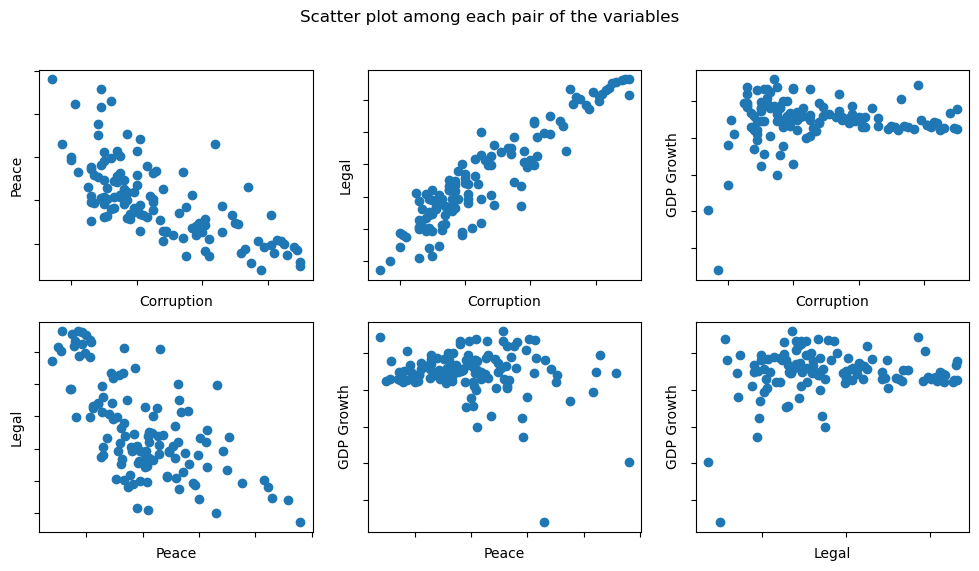

In [5]:
# Create subplots for scatter plots
fig, axs = plt.subplots(2, 3,figsize=(12,6))
fig.suptitle('Scatter plot among each pair of the variables')
Labels = ['Corruption', 'Peace', 'Legal', 'GDP Growth']

# Iterate through the pairs of variables for plotting
m = 0
for i in range(len(Labels)-1): 
    for j in range(1,len(Labels)-i):
        axs.flat[m].scatter(raw[Labels[i]],raw[Labels[i+j]]) # Scatter plot for each pair of variables
        axs.flat[m].set_xlabel(Labels[i]) # Set x-axis label
        axs.flat[m].set_ylabel(Labels[i+j]) # Set y-axis label
        # Turn off tick labels.
        axs.flat[m].set_yticklabels([])
        axs.flat[m].set_xticklabels([])
        m = m+1

### Plot histogram

Note that the distribution for GDP Growth is quite skewed.

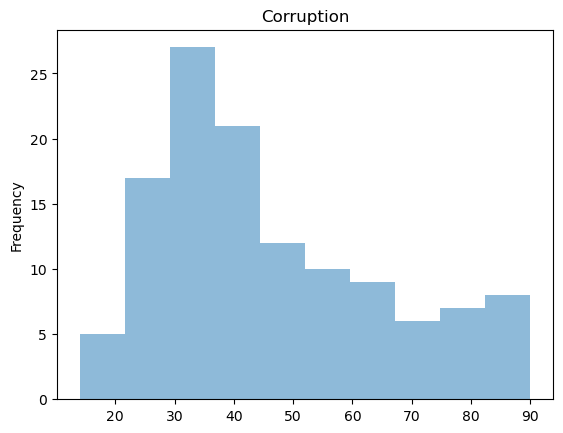

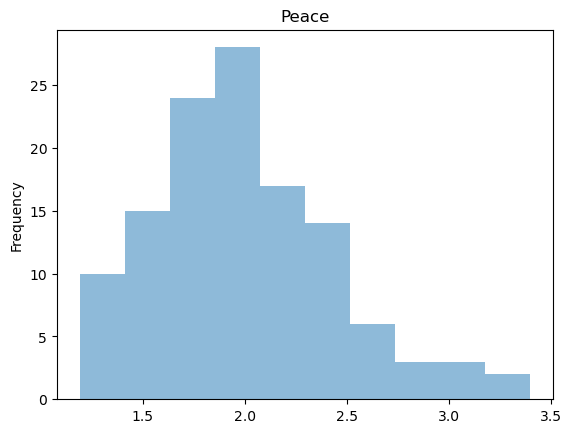

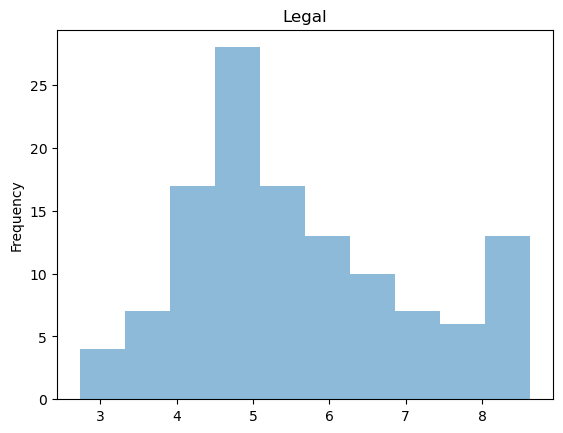

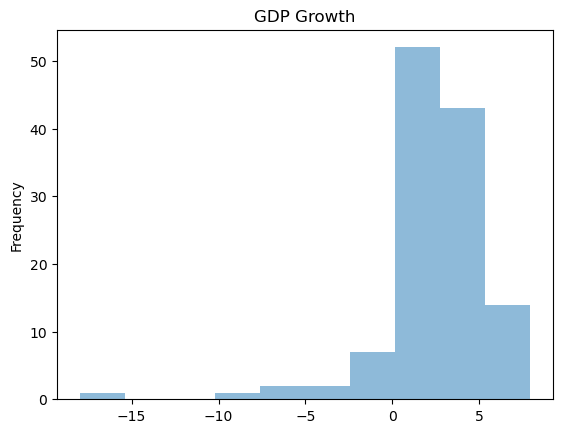

In [7]:
# Create histograms for each variable
plt.figure(1)
raw['Corruption'].plot(kind = 'hist', title = 'Corruption', alpha = 0.5)

plt.figure(2)
raw['Peace'].plot(kind = 'hist', title = 'Peace', alpha = 0.5)

plt.figure(3)
raw['Legal'].plot(kind = 'hist', title = 'Legal', alpha = 0.5)

plt.figure(4)
raw['GDP Growth'].plot(kind = 'hist', title = 'GDP Growth', alpha = 0.5)

plt.show()

## K-means cluster

### Pick features and normalization

Let's normalize all the features, effectively making them equally weighted.

In [9]:
X = raw[['Corruption', 'Peace', 'Legal', 'GDP Growth']]
X = (X - X.mean()) / X.std()
print(X.head(5))

   Corruption     Peace     Legal  GDP Growth
0   -0.378414 -0.305319 -1.194666    0.317896
1   -0.639833  0.467304 -0.967413    0.564392
2   -0.535266 -0.104348 -0.693096   -1.440899
3   -0.692117  0.478469 -0.990273   -0.667782
4    1.712936 -1.202990  1.778450    0.030368


### Perform elbow method

The marginal gain of adding one cluster dropped quite a bit from k=3 to k=4. We will choose k=3 (not a clear cut though).

<function matplotlib.pyplot.show(close=None, block=None)>

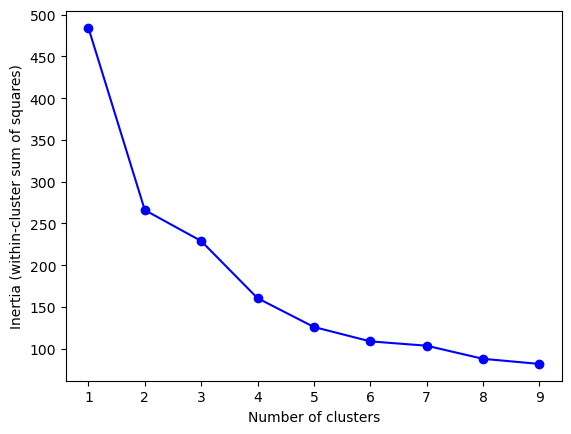

In [11]:
Ks = range(1,10)
inertia = [KMeans(i).fit(X).inertia_ for i in Ks]
fig = plt.figure()
plt.plot(Ks, inertia, '-bo')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.show

### K-means with k = 3

In [13]:
k = 3
kmeans = KMeans(n_clusters=k,random_state=0)
kmeans.fit(X)

# Print the inertia of the KMeans model for k=3
print("inertia for k=3 is", np.round(kmeans.inertia_,3))

Cluster_Table = pd.DataFrame(data=kmeans.cluster_centers_, columns=['Corruption', 'Peace', 'Legal', 'GDP Growth'])
Cluster_Table['Cluster'] = Cluster_Table.index
print("\ncluster centers:\n" )
print(Cluster_Table.to_string(index=False))

# Assign cluster labels to the original data
raw[ 'Cluster Lables' ]=kmeans.labels_ 
pd.set_option("display.max_rows", None) # Set option to display all rows of the DataFrame
raw

inertia for k=3 is 190.196

cluster centers:

 Corruption     Peace     Legal  GDP Growth  Cluster
  -0.474268  0.263118 -0.424249    0.409933        0
   1.226295 -0.975165  1.161167    0.010228        1
  -0.971989  1.215626 -1.016771   -1.614970        2


,Country,Abbrev,Corruption,Peace,Legal,GDP Growth,Cluster Lables
0,Albania,AL,39,1.867,3.822,3.403,0
1,Algeria,DZ,34,2.213,4.160,4.202,0
2,Argentina,AR,36,1.957,4.568,-2.298,2
3,Armenia,AM,33,2.218,4.126,0.208,2
4,Australia,AU,79,1.465,8.244,2.471,1
5,Austria,AT,75,1.278,8.012,1.482,1
6,Azerbaijan,AZ,30,2.450,3.946,-3.772,2
7,Bahrain,BH,43,2.398,6.157,2.915,0
8,Bangladesh,BD,26,2.045,3.117,6.923,0
9,Belgium,BE,77,1.528,7.839,1.239,1


### From the cluster centers, it appears that cluster 0 contains the countries with lowest risk, cluster 2 contains countries with medium risk and cluster 1 contains countries with highest risk 

### Visualize the result (2D plots)

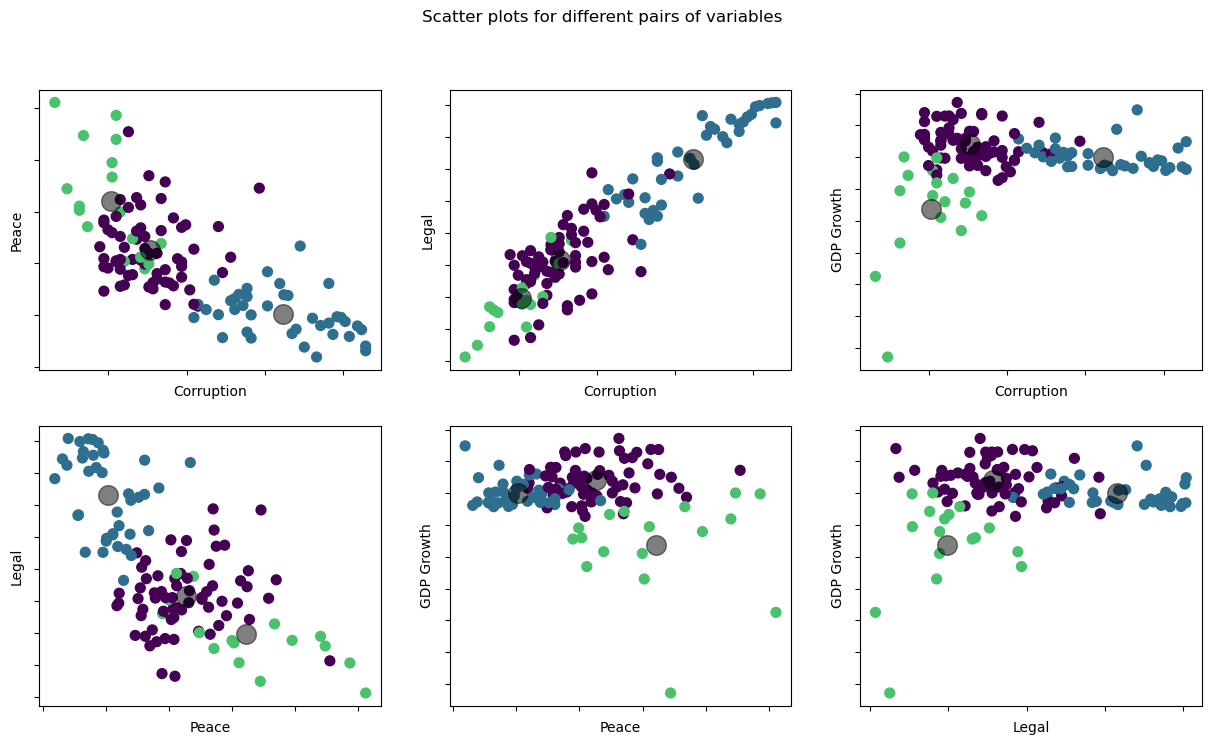

In [15]:
# Scatter plots of different pairs of variables
fig, axs = plt.subplots(2, 3,figsize=(15,8))
fig.suptitle('Scatter plots for different pairs of variables')
Labels = ['Corruption', 'Peace', 'Legal', 'GDP Growth']
y = kmeans.labels_

# Normalize the cluster labels for coloring
norm = clrs.Normalize(vmin=0., vmax=y.max()+0.8)
cmap = cm.viridis

# Plot the Figure
m = 0
for i in range(len(Labels)-1): 
    for j in range(1,len(Labels)-i):
        axs.flat[m].scatter(X[Labels[i]], X[Labels[i+j]], c=cmap(norm(y)), s=50)
        axs.flat[m].scatter(Cluster_Table[Labels[i]], Cluster_Table[Labels[i+j]], c='black', s=200, alpha=0.5)
        
        axs.flat[m].set_xlabel(Labels[i])
        axs.flat[m].set_ylabel(Labels[i+j])
        
        axs.flat[m].set_yticklabels([]) # Turn off y-tick labels for cleaner visualization
        axs.flat[m].set_xticklabels([]) # Turn off x-tick labels for cleaner visualization
        m = m+1

### Visualize the result (2D plots with names of countries)

plot country abbreviations instead of dots.

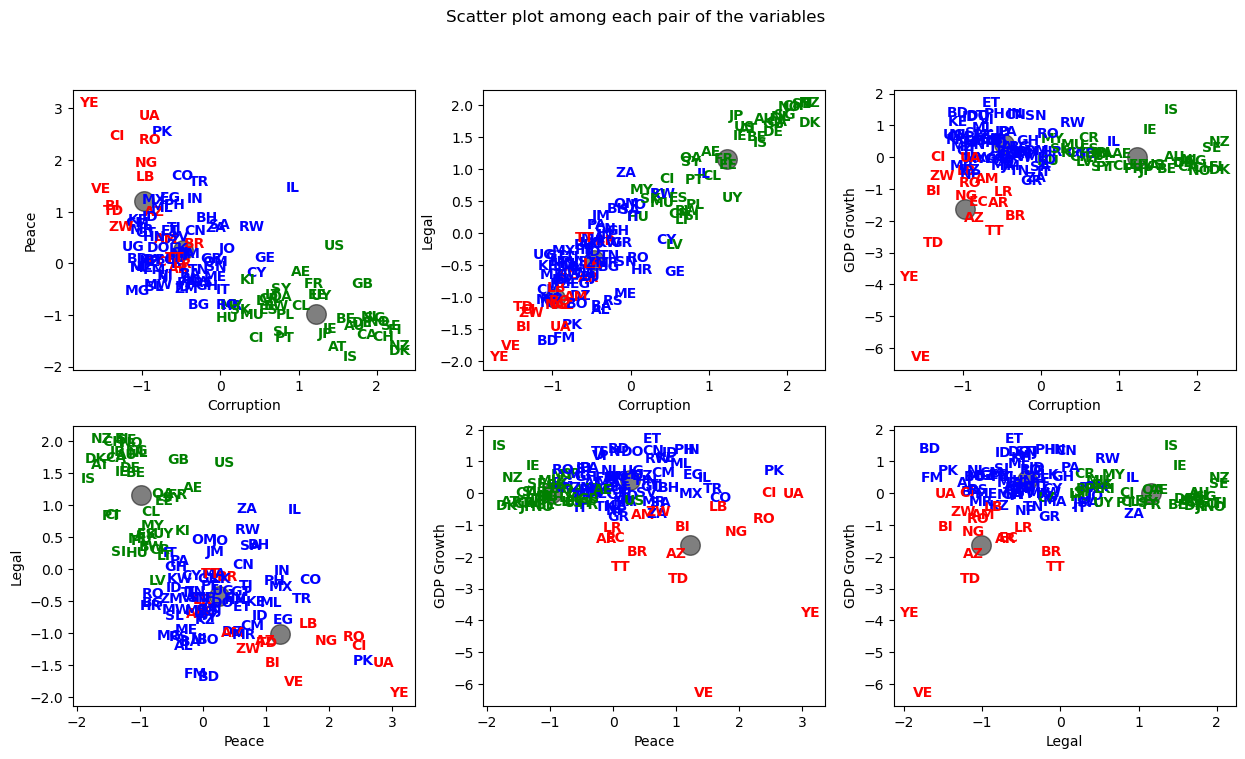

In [17]:
# Plot of the Scatter Figure among each pair
fig, axs = plt.subplots(2, 3,figsize=(15,8))
fig.suptitle('Scatter plot among each pair of the variables')
Labels=['Corruption', 'Peace', 'Legal', 'GDP Growth']
colors = ['blue', 'green', 'red']

# set up the color
norm = clrs.Normalize(vmin=0., vmax=y.max()+0.8)
cmap = cm.viridis

# Begin plotting of scatter plot with abbreviations
m = 0
for i in range(len(Labels)-1): 
    for j in range(1,len(Labels)-i):
        axs.flat[m].scatter(X[Labels[i]],X[Labels[i+j]],c=y, s=0, alpha=0)
        axs.flat[m].scatter(Cluster_Table[Labels[i]], Cluster_Table[Labels[i+j]], c='black', s=200, alpha=0.5)
        axs.flat[m].set_xlabel(Labels[i])
        axs.flat[m].set_ylabel(Labels[i+j])
        for h in range(X.shape[0]):
            axs.flat[m].text(X[Labels[i]].iloc[h], X[Labels[i+j]].iloc[h], raw['Abbrev'].iloc[h],
                             color=colors[y[h]], weight='semibold', horizontalalignment = 'center', verticalalignment = 'center')
        m = m+1

### List the result

In [19]:
result = pd.DataFrame({'Country':raw['Country'], 'Abbrev':raw['Abbrev'], 'Label':y})
with pd.option_context('display.max_rows', None, 'display.max_columns', 3):
    print(result.sort_values(by=['Label', 'Country']))

                          Country Abbrev  Label
0                         Albania     AL      0
1                         Algeria     DZ      0
7                         Bahrain     BH      0
8                      Bangladesh     BD      0
10                          Benin     BJ      0
11                        Bolivia     BO      0
12         Bosnia and Herzegovina     BA      0
15                       Bulgaria     BG      0
17                       Cameroon     CM      0
21                          China     CN      0
22                       Colombia     CO      0
24                        Croatia     HR      0
25                         Cyprus     CY      0
29             Dominican Republic     DO      0
31                          Egypt     EG      0
32                    El Salvador     SV      0
34                       Ethiopia     ET      0
37                          Gabon     GA      0
38                        Georgia     GE      0
40                          Ghana     GH

### Since Corruption and Legal are highly correlated, we drop the Corruption variable, l.e., we pick three features for this analysis, Peace, Legal and GDP Growth.

In [21]:
X = X[['Peace', 'Legal', 'GDP Growth']]

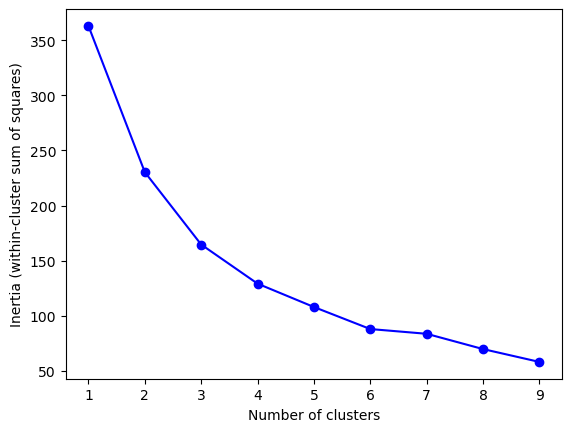

In [22]:
Ks = range(1, 10)
inertia = [KMeans(i).fit(X).inertia_ for i in Ks]

fig = plt.figure()
plt.plot(Ks, inertia, '-bo')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.show()

### K-means with k = 3

In [24]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X)

# print inertia & cluster center
print("inertia for k=3 is", np.round(kmeans.inertia_,3))

Cluster_Table = pd.DataFrame(data=kmeans.cluster_centers_, columns=['Peace', 'Legal', 'GDP Growth'])
Cluster_Table['Cluster'] = Cluster_Table.index
print("\ncluster centers:\n")
print(Cluster_Table.to_string(index=False))

# Assign cluster labels to the original DataFrame
raw['Cluster Lables']=kmeans.labels_ 
pd.set_option("display.max_rows", None) # Set option to display all rows of the DataFrame
raw

inertia for k=3 is 157.551

cluster centers:

    Peace     Legal  GDP Growth  Cluster
 0.253209 -0.451868    0.431274        0
-0.928106  1.166413   -0.014458        1
 1.215626 -1.016771   -1.614970        2


,Country,Abbrev,Corruption,Peace,Legal,GDP Growth,Cluster Lables
0,Albania,AL,39,1.867,3.822,3.403,0
1,Algeria,DZ,34,2.213,4.160,4.202,0
2,Argentina,AR,36,1.957,4.568,-2.298,2
3,Armenia,AM,33,2.218,4.126,0.208,2
4,Australia,AU,79,1.465,8.244,2.471,1
5,Austria,AT,75,1.278,8.012,1.482,1
6,Azerbaijan,AZ,30,2.450,3.946,-3.772,2
7,Bahrain,BH,43,2.398,6.157,2.915,0
8,Bangladesh,BD,26,2.045,3.117,6.923,0
9,Belgium,BE,77,1.528,7.839,1.239,1


It appears that Cluster 1 contains the countries with lowest risk, Cluster 0 contains the countries with medium risk, and Cluster 2 contain the countries with highest risk.

### Visualize the result (2D plots)

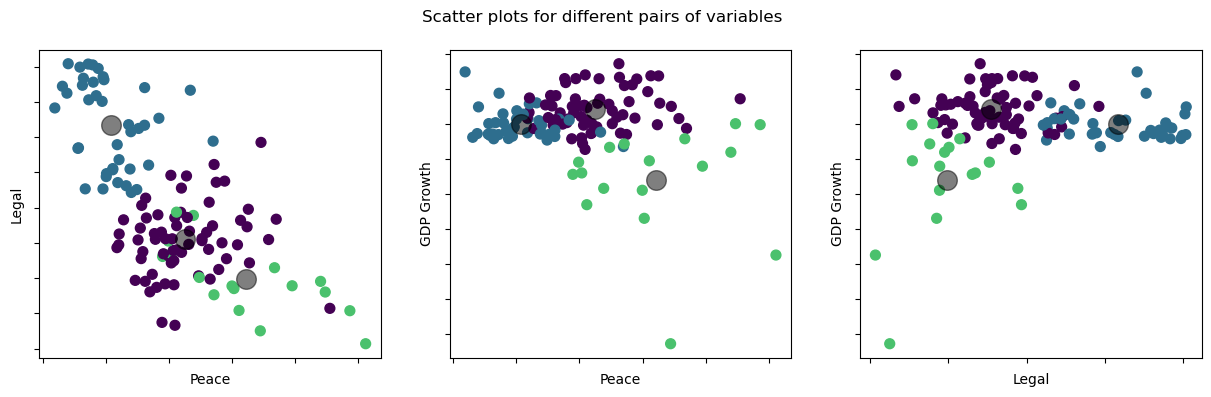

In [27]:
# Scatter plots of different pairs of variables
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.suptitle('Scatter plots for different pairs of variables')
Labels = ['Peace', 'Legal', 'GDP Growth']
y = kmeans.labels_

# set up the color
norm = clrs.Normalize(vmin=0.,vmax=y.max()+0.8)
cmap = cm.viridis

# Plot the Figure
m = 0
for i in range(len(Labels)-1):
    for j in range(1,len(Labels)-i):
        axs.flat[m].scatter(X[Labels[i]], X[Labels[i+j]], c=cmap(norm(y)), s=50)
        axs.flat[m].scatter(Cluster_Table[Labels[i]], Cluster_Table[Labels[i+j]], c='black', s=200, alpha=0.5)

        axs.flat[m].set_xlabel(Labels[i])
        axs.flat[m].set_ylabel(Labels[i+j])
        # Turn off tick labels.
        axs.flat[m].set_yticklabels([])
        axs.flat[m].set_xticklabels([])
        m = m+1

### Visualize the result (2D plots with names of countries)

plot country abbreviations instead of dots

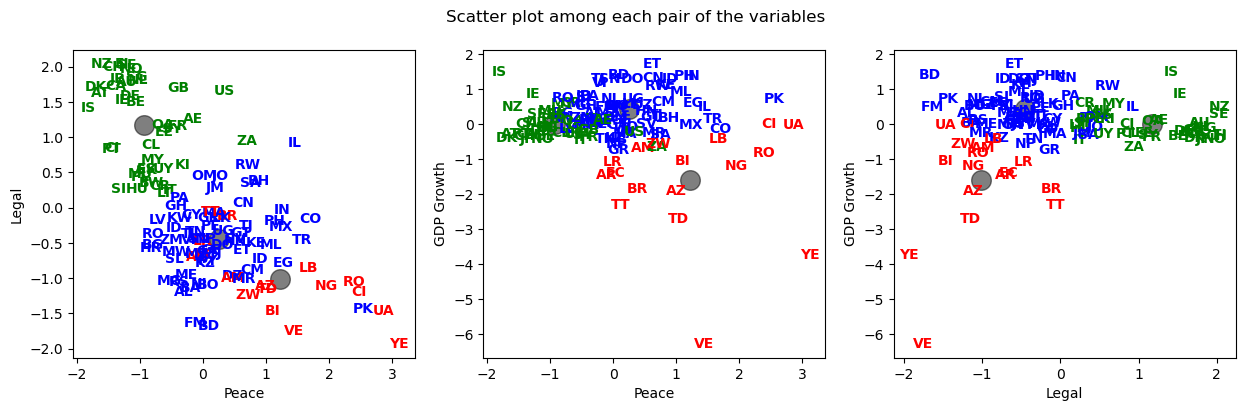

In [29]:
# Plot of the Scatter Figure among each pair
fig, axs = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Scatter plot among each pair of the variables')
Labels=['Peace', 'Legal', 'GDP Growth']
colors = ['blue', 'green', 'red']

# set up the color
norm = clrs.Normalize(vmin=0.,vmax=y.max()+0.8)
cmap = cm.viridis

# Plot the Figure
m = 0
for i in range(len(Labels)-1):
    for j in range(1,len(Labels)-i):
        axs.flat[m].scatter(X[Labels[i]], X[Labels[i+j]], c=y, s=0, alpha=0)
        axs.flat[m].scatter(Cluster_Table[Labels[i]], Cluster_Table[Labels[i+j]], c='black', s=200, alpha=0.5)
        
        axs.flat[m].set_xlabel(Labels[i])
        axs.flat[m].set_ylabel(Labels[i+j])
        for h in range(X.shape[0]):
            axs.flat[m].text(X[Labels[i]].iloc[h], X[Labels[i+j]].iloc[h], raw['Abbrev'].iloc[h],
                             color=colors[y[h]], weight='semibold', horizontalalignment = 'center', verticalalignment = 'center')
        m = m+1

### Visualize the result (3D plot)

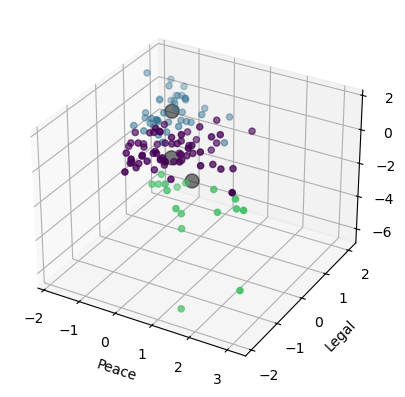

In [31]:
# set up the color
norm = clrs.Normalize(vmin=0.,vmax=y.max()+0.8)
cmap = cm.viridis

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X.iloc[:,0], X.iloc[:,1], X.iloc[:,2], c=cmap(norm(y)), marker='o')

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

ax.set_xlabel('Peace')
ax.set_ylabel('Legal')
ax.set_zlabel('GDP Growth')

plt.show()

### List the result

In [33]:
result = pd.DataFrame({'Country':raw['Country'], 'Abbrev':raw['Abbrev'], 'Label':y})
with pd.option_context('display.max_rows', None, 'display.max_columns', 3):
    print(result.sort_values(by=['Label', 'Country']))

                          Country Abbrev  Label
0                         Albania     AL      0
1                         Algeria     DZ      0
7                         Bahrain     BH      0
8                      Bangladesh     BD      0
10                          Benin     BJ      0
11                        Bolivia     BO      0
12         Bosnia and Herzegovina     BA      0
15                       Bulgaria     BG      0
17                       Cameroon     CM      0
21                          China     CN      0
22                       Colombia     CO      0
24                        Croatia     HR      0
25                         Cyprus     CY      0
29             Dominican Republic     DO      0
31                          Egypt     EG      0
32                    El Salvador     SV      0
34                       Ethiopia     ET      0
37                          Gabon     GA      0
38                        Georgia     GE      0
40                          Ghana     GH